In [1]:
# ===== DATE SELECTION KNOB =====
# Leave empty [] to process all dates, or specify one or more dates as strings in "YYYYMMDD" format
# selected_dates = [] # for all dates
selected_dates = ["20260206"]  # <-- MODIFY THIS to select specific dates

# ===== PLOT SETTINGS ===== CHANGE AS NEEDED =====
plot_all_traces = "Y"  # "Y" to plot all, "N" to skip; high current traces are always plotted

In [ ]:
# ===== DISCOVER AND OPTIONAL PLOT BY DATE/TIME =====
# Find all unique date/time combinations and plot them chronologically (if enabled)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt
from pathlib import Path
from datetime import datetime, timedelta

data_folder = Path("/Users/xylu/Desktop/Data/electrode_local")
beam_folder = Path("/Volumes/ahfb1")

all_files = sorted(data_folder.glob("*.csv"))

print(f"Total electrode files found: {len(all_files)}")
print(f"Beam folder: {beam_folder}")
print(f"Beam folder exists: {beam_folder.exists()}")

# Extract unique (date, time) pairs
date_time_pairs = set()
for file in all_files:
    stem = file.stem
    parts = stem.split('_')
    if len(parts) >= 2:
        date_str = parts[0]
        time_str = parts[1]
        date_time_pairs.add((date_str, time_str))

# Sort chronologically
sorted_date_times = sorted(date_time_pairs, key=lambda x: (x[0], x[1]))

# Filter by selected dates if specified
if selected_dates:
    # Convert selected_dates to strings for comparison
    selected_dates_str = [str(d) for d in selected_dates]
    sorted_date_times = [dt for dt in sorted_date_times if dt[0] in selected_dates_str]
    print(f"Filtering to {len(sorted_date_times)} date/time combination(s) matching selected dates: {selected_dates}\n")
else:
    print(f"Found {len(sorted_date_times)} unique date/time combinations:\n")

# for date_str, time_str in sorted_date_times:
#     print(f"  {date_str} {time_str}")

# Pre-calculated time shifts for each file type (in µs). These shifts align the rising edge to the target times
time_shifts = {
    'rfd4tbs2': 8.707,     # edge -3.050 -> target 5.657
    'rfd10tbs1': 10.320,   # edge -4.625 -> target 5.695
    'rfd11tbs1': -0.205,   # edge 6.400 -> target 6.195
    'rfd11tbs2': -0.205    # edge 6.400 -> target 6.195
}

# Channel colors
color_map = {'CH1': '#d62728', 'CH2': 'blue', 'CH3': 'green'}

# ===== BEAM POSITION FILE MATCHING =====

def parse_beam_filename(filename):
    """Extract date and time from beam filename like 'HERDH_06_Feb_2026_10_57_35.igp'
    
    Returns:
        dict: Contains 'date' (YYYYMMDD), 'hhmm' (HHMM), 'full_time', 'beam_type' (HERDH or HERDV)
    """
    stem = filename.stem
    parts = stem.split('_')
    
    # Expected format: HERDH_06_Feb_2026_10_57_35
    if len(parts) >= 6:
        beam_type = parts[0]  # HERDH or HERDV
        day = parts[1]
        month_str = parts[2]  # Feb
        year = parts[3]
        hour = parts[4]
        minute = parts[5]
        second = parts[6] if len(parts) > 6 else "00"
        
        # Convert month to number
        month_dict = {'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
                      'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'}
        month = month_dict.get(month_str, '00')
        
        date_str = f"{year}{month}{day.zfill(2)}"
        hhmm_str = f"{hour.zfill(2)}{minute.zfill(2)}"
        full_time = f"{hour.zfill(2)}:{minute.zfill(2)}:{second.zfill(2)}"
        
        return {
            'date': date_str,
            'hhmm': hhmm_str,
            'full_time': full_time,
            'beam_type': beam_type,
            'filename': filename.name
        }
    return None

def find_matching_beam_files(date_str, time_str, beam_folder, time_tolerance_min=1):
    """Find beam files matching electrode file date/time with tolerance.
    
    Args:
        date_str: Date in YYYYMMDD format
        time_str: Time in HHMMSS format (6 digits)
        beam_folder: Path to beam files folder
        time_tolerance_min: Maximum time difference in minutes before warning
    
    Returns:
        dict: Keys are beam_type ('HERDH', 'HERDV'), values are file paths and time info
    """
    if not beam_folder.exists():
        return {}
    
    # Convert electrode time to datetime for comparison
    # time_str is in HHMMSS format (6 digits from filename like "001521")
    try:
        electrode_dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
    except:
        return {}
    
    matching_beams = {}
    
    # Search for beam files with same date
    # Format: HERDH_DD_MMM_YYYY_HH_MM_SS.igp or HERDV_DD_MMM_YYYY_HH_MM_SS.igp
    pattern = f"*_{date_str[6:8]}_*_{date_str[0:4]}_*.igp"
    beam_files = sorted(beam_folder.glob(pattern))
    
    for beam_file in beam_files:
        beam_info = parse_beam_filename(beam_file)
        if beam_info is None:
            continue
        
        if beam_info['date'] != date_str:
            continue
        
        # Parse beam file time (beam filename includes seconds, e.g., 00_15_22)
        try:
            beam_hhmm = beam_info['hhmm']
            # Extract seconds from full_time (format: "HH:MM:SS")
            beam_full_time = beam_info['full_time']
            beam_hhmmss = beam_full_time.replace(':', '')  # "001522"
            beam_dt = datetime.strptime(date_str + beam_hhmmss, "%Y%m%d%H%M%S")
        except:
            continue
        
        # Calculate time difference in minutes (but show to nearest second)
        time_diff_seconds = abs((beam_dt - electrode_dt).total_seconds())
        time_diff_minutes = time_diff_seconds / 60  # in minutes
        
        beam_type = beam_info['beam_type']
        
        if beam_type not in matching_beams or time_diff_minutes < matching_beams[beam_type]['time_diff']:
            matching_beams[beam_type] = {
                'file': beam_file,
                'time_diff': time_diff_minutes,
                'full_time': beam_info['full_time'],
                'hhmm': beam_hhmm,
                'filename': beam_info['filename']
            }
    
    return matching_beams

def load_beam_file_as_image(file_path):
    """Load binary IGP file as 16-bit signed integer data (beam position/intensity).
    
    Returns:
        np.ndarray: 2D image array of beam position data
    """
    try:
        data = np.fromfile(file_path, dtype=np.int16)
        
        # Reshape based on typical beam camera dimensions
        # 983040 bytes = 491520 int16 values
        # Common dimensions: 512x960, 640x768, etc.
        # Let's try 512x960 first
        total_pixels = len(data)
        
        # Try common dimensions
        for h, w in [(512, 960), (640, 768), (480, 1024), (1024, 480)]:
            if h * w == total_pixels:
                return data.reshape(h, w)
        
        # If no standard dimensions match, try to find square-ish dimensions
        sqrt_val = int(np.sqrt(total_pixels))
        if sqrt_val * sqrt_val == total_pixels:
            return data.reshape(sqrt_val, sqrt_val)
        
        # Fallback: return 1D data for analysis
        return data.reshape(-1, 1)
    
    except Exception as e:
        print(f"Error loading beam file: {e}")
        return None

# ===== HELPER FUNCTIONS =====

def group_files_by_rfd(matching_files):
    """Group and sort files by RFD type and TBS value."""
    rfd4_files = sorted([f for f in matching_files if 'rfd4' in f.name])
    rfd10_files = sorted([f for f in matching_files if 'rfd10' in f.name])
    rfd11_files = sorted([f for f in matching_files if 'rfd11' in f.name])
    
    # Sort within each RFD by TBS value
    rfd4_files = sorted(rfd4_files, key=lambda f: int(f.stem.split('tbs')[1]) if 'tbs' in f.stem else 0)
    rfd10_files = sorted(rfd10_files, key=lambda f: int(f.stem.split('tbs')[1]) if 'tbs' in f.stem else 0)
    rfd11_files = sorted(rfd11_files, key=lambda f: int(f.stem.split('tbs')[1]) if 'tbs' in f.stem else 0)
    
    # Combine in order: rfd4, rfd10, rfd11
    return rfd4_files + rfd10_files + rfd11_files


def read_and_process_file(file_path):
    """Read file, apply filter, and convert to current in mA.
    
    Returns:
        dict: Contains 'df', 'channels', 'raw_current_data', 'current_data', 'time_us', 'is_rfd11', 'peak_currents', 'ntrigger'
    """
    title_name = file_path.name
    is_rfd11 = 'rfd11' in title_name
    
    # Detect header row (older files have 4 header lines, newer ones may have 5 due to Ntrigger)
    skip_rows = 4
    ntrigger_val = None
    try:
        with open(file_path, 'r', errors='ignore') as f:
            for i in range(15):
                line = f.readline()
                if "Ntrigger" in line:
                    parts = line.split(',')
                    if len(parts) >= 2:
                        ntrigger_val = parts[1].strip()
                if line.startswith('CH1'):
                    skip_rows = i
                    break
    except Exception:
        pass
    
    # Read appropriate channels
    if is_rfd11:
        df = pd.read_csv(file_path, skiprows=skip_rows, usecols=['CH1', 'CH2', 'CH3'])
        channels = ['CH1', 'CH2', 'CH3']
    else:
        df = pd.read_csv(file_path, skiprows=skip_rows, usecols=['CH1'])
        channels = ['CH1']
    
    # Calculate time in microseconds
    ### Physics Line ###
    time_us = np.arange(len(df)) * 75e-9 * 1e6 - 1400
    
    # Extract file identifier and apply time shift
    file_id = file_path.stem.split('_')[-1]  # e.g., 'rfd4tbs2'
    if file_id in time_shifts:
        time_us = time_us + time_shifts[file_id]
    
    # Process each channel
    raw_current_data = {}
    current_data = {}
    peak_currents = {}
    
    for ch_name in channels:
        ch_data = df[ch_name].values.copy()
        
        # Convert raw data to current in mA first
        ### Physics Line ###
        raw_current_mA = ch_data / 10/50 * 1000  # Note:10 times voltage probe, 50 ohm resistor, convert to mA
        raw_current_data[ch_name] = raw_current_mA
        
        # Apply 20-point moving average filter to raw current
        ### Physics Line ###
        window_size = 20
        filtered_current_mA = np.convolve(raw_current_mA, np.ones(window_size)/window_size, mode='same')
        current_data[ch_name] = filtered_current_mA
        
        # Calculate peak from filtered data
        peak_currents[ch_name] = np.max(np.abs(filtered_current_mA))
    
    return {
        'df': df,
        'channels': channels,
        'raw_current_data': raw_current_data,
        'current_data': current_data,
        'time_us': time_us,
        'is_rfd11': is_rfd11,
        'peak_currents': peak_currents,
        'filename': title_name,
        'ntrigger': ntrigger_val
    }


# ===== PROCESS ALL FILES ONCE AND STORE RESULTS =====
print("\n" + "="*60)
print("PROCESSING ALL FILES")
print("="*60)

all_file_data = []  # Store all processed file data
time_mismatch_warnings = []  # Track time mismatches

for date_str, time_str in sorted_date_times:
    search_pattern = f"{date_str}_{time_str}_*.csv"
    matching_files = sorted(data_folder.glob(search_pattern))
    
    if not matching_files:
        continue
    
    # Group by RFD type and TBS value
    file_paths = group_files_by_rfd(matching_files)
    
    if not file_paths:
        continue
    
    print(f"\n{date_str} {time_str}: Processing {len(file_paths)} electrode files...")
    
    # Find matching beam files
    matching_beams = find_matching_beam_files(date_str, time_str, beam_folder)
    
    # Check for time mismatches and generate warnings
    for beam_type, beam_info in matching_beams.items():
        time_diff = beam_info['time_diff']
        if time_diff > 1:
            warning_msg = f"⚠️  TIME MISMATCH: {date_str} {time_str} vs {beam_type} {beam_info['full_time']} (diff: {time_diff:.1f} min)"
            time_mismatch_warnings.append(warning_msg)
            print(f"  {warning_msg}")
        else:
            print(f"  ✓ {beam_type} matched within {time_diff:.1f} min")
    
    # Process each electrode file
    for file_path in file_paths:
        try:
            file_data = read_and_process_file(file_path)
            file_data['date'] = date_str
            file_data['time'] = time_str
            file_data['beam_files'] = matching_beams  # Attach beam file info
            all_file_data.append(file_data)
            print(f"  ✓ {file_data['filename']}")
        except Exception as e:
            print(f"  ✗ Error processing {file_path.name}: {e}")

print(f"\nSuccessfully processed {len(all_file_data)} electrode files.")

if time_mismatch_warnings:
    print(f"\n⚠️  WARNING: Found {len(time_mismatch_warnings)} time mismatches (>1 min):")
    for warning in time_mismatch_warnings:
        print(f"    {warning}")
else:
    print(f"\n✓ All beam/electrode file pairs within 1 minute tolerance!")


Total electrode files found: 1126
Beam folder: /Volumes/ahfb1
Beam folder exists: True
Filtering to 4 date/time combination(s) matching selected dates: ['20260206']


PROCESSING ALL FILES

20260206 001521: Processing 4 electrode files...
  ✓ 20260206_001521_rfd4tbs2.csv
  ✓ 20260206_001521_rfd10tbs1.csv
  ✓ 20260206_001521_rfd11tbs1.csv
  ✓ 20260206_001521_rfd11tbs2.csv

20260206 050910: Processing 1 electrode files...
  ✓ 20260206_050910_rfd10tbs2.csv

20260206 051022: Processing 1 electrode files...
  ✓ 20260206_051022_rfd10tbs2.csv

20260206 064319: Processing 4 electrode files...
  ✓ 20260206_064319_rfd4tbs2.csv
  ✓ 20260206_064319_rfd10tbs1.csv
  ✓ 20260206_064319_rfd11tbs1.csv
  ✓ 20260206_064319_rfd11tbs2.csv

Successfully processed 10 electrode files.

✓ All beam/electrode file pairs within 1 minute tolerance!


In [3]:
# ## Plotting of shots of concern after handpicking

# # Manual list of files with comments
# manual_files = [
#     ("20260127_001140_rfd11tbs1.csv", "Beam loss"),
#     ("20260127_001256_rfd11tbs1.csv", "Beam loss"),
#     ("20260127_023619_rfd11tbs1.csv", "Beam loss + CH1 failure"),
#     ("20260127_023730_rfd11tbs1.csv", "Beam loss"),
#     ("20260127_121328_rfd10tbs1.csv", "Small (?) Photocurrent"),
#     ("20260127_123338_rfd10tbs1.csv", "Small (?) Photocurrent"),
#     ("20260127_182952_rfd11tbs2.csv", "CH1 failure"),
#     ("20260128_021808_rfd11tbs1.csv", "CH2 failure"),
#     ("20260128_025331_rfd10tbs1.csv", "Photocurrent"),
#     ("20260128_074626_rfd11tbs1.csv", "CH1 failure"),
#     ("20260128_190150_rfd10tbs1.csv", "Photocurrent"),
#     ("20260128_205419_rfd10tbs1.csv", "Photocurrent"),
#     ("20260128_212802_rfd10tbs1.csv", "Photocurrent"),
#     ("20260129_101740_rfd10tbs2.csv", "CH1 failure"),
#     ("20260129_101918_rfd10tbs1.csv", "Photocurrent"),
#     ("20260129_170301_rfd10tbs3.csv", "CH1 failure"),
#     ("20260130_184850_rfd10tbs3.csv", "CH1 failure"),
# ]

# print("="*60)
# print("PLOTTING MANUALLY SELECTED FILES")
# print("="*60)

# # Plot each manually selected file
# for filename, comment in manual_files:
#     # Find the file_data for this filename
#     file_data = None
#     for data in all_file_data:
#         if data['filename'] == filename:
#             file_data = data
#             break
    
#     if file_data is None:
#         print(f"\nWarning: {filename} not found in processed data")
#         continue
    
#     # Set y-axis limits based on comment
#     if 'photocurrent' in comment.lower():
#         ylim = (-6, 6)
#     else:
#         ylim = (-100, 100)
    
#     # Create plot with 2 subplots (raw on left, filtered on right)
#     fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
#     # Left plot: Raw current
#     for ch_name in file_data['channels']:
#         raw_current_mA = file_data['raw_current_data'][ch_name]
        
#         if file_data['is_rfd11']:
#             axes[0].plot(file_data['time_us'], raw_current_mA, color=color_map[ch_name], 
#                    linewidth=1.5, marker=None, markersize=1, alpha=0.7, label=ch_name)
#         else:
#             axes[0].plot(file_data['time_us'], raw_current_mA, color='black', 
#                    linewidth=2, marker=None, markersize=1, alpha=0.7)
    
#     axes[0].set_xlabel('Time (µs)', fontsize=12)
#     axes[0].set_ylabel('Current (mA)', fontsize=12)
#     axes[0].set_title(f'{filename} - Raw\n{comment}', fontsize=11, fontweight='bold', color='red')
#     axes[0].grid(True, alpha=0.3)
#     axes[0].tick_params(labelsize=10)
#     axes[0].set_ylim(ylim)
#     axes[0].set_xlim(-1450, 200)
    
#     if file_data['is_rfd11']:
#         axes[0].legend(fontsize=10, loc='upper right')
    
#     # Right plot: Filtered current
#     for ch_name in file_data['channels']:
#         filtered_current_mA = file_data['current_data'][ch_name]
        
#         if file_data['is_rfd11']:
#             axes[1].plot(file_data['time_us'], filtered_current_mA, color=color_map[ch_name], 
#                    linewidth=1.5, marker=None, markersize=1, alpha=0.7, label=ch_name)
#         else:
#             axes[1].plot(file_data['time_us'], filtered_current_mA, color='black', 
#                    linewidth=2, marker=None, markersize=1, alpha=0.7)
    
#     axes[1].set_xlabel('Time (µs)', fontsize=12)
#     axes[1].set_ylabel('Current (mA)', fontsize=12)
#     axes[1].set_title(f'{filename} - Filtered (20-pt avg)\n{comment}', fontsize=11, fontweight='bold', color='red')
#     axes[1].grid(True, alpha=0.3)
#     axes[1].tick_params(labelsize=10)
#     axes[1].set_ylim(ylim)
#     axes[1].set_xlim(-1450, 200)
    
#     if file_data['is_rfd11']:
#         axes[1].legend(fontsize=10, loc='upper right')
    
#     plt.rcParams['figure.dpi'] = 150
#     plt.rcParams['savefig.dpi'] = 300
#     plt.tight_layout()
#     plt.show()
    
#     print(f"Plotted: {filename} - {comment}")

# print(f"\nCompleted plotting {len(manual_files)} manually selected files.")


PLOTTING ELECTRODE SIGNALS WITH BEAM POSITIONS

Plotting: 20260206 001521 (4 electrode files)
  No beam files found for this timestamp


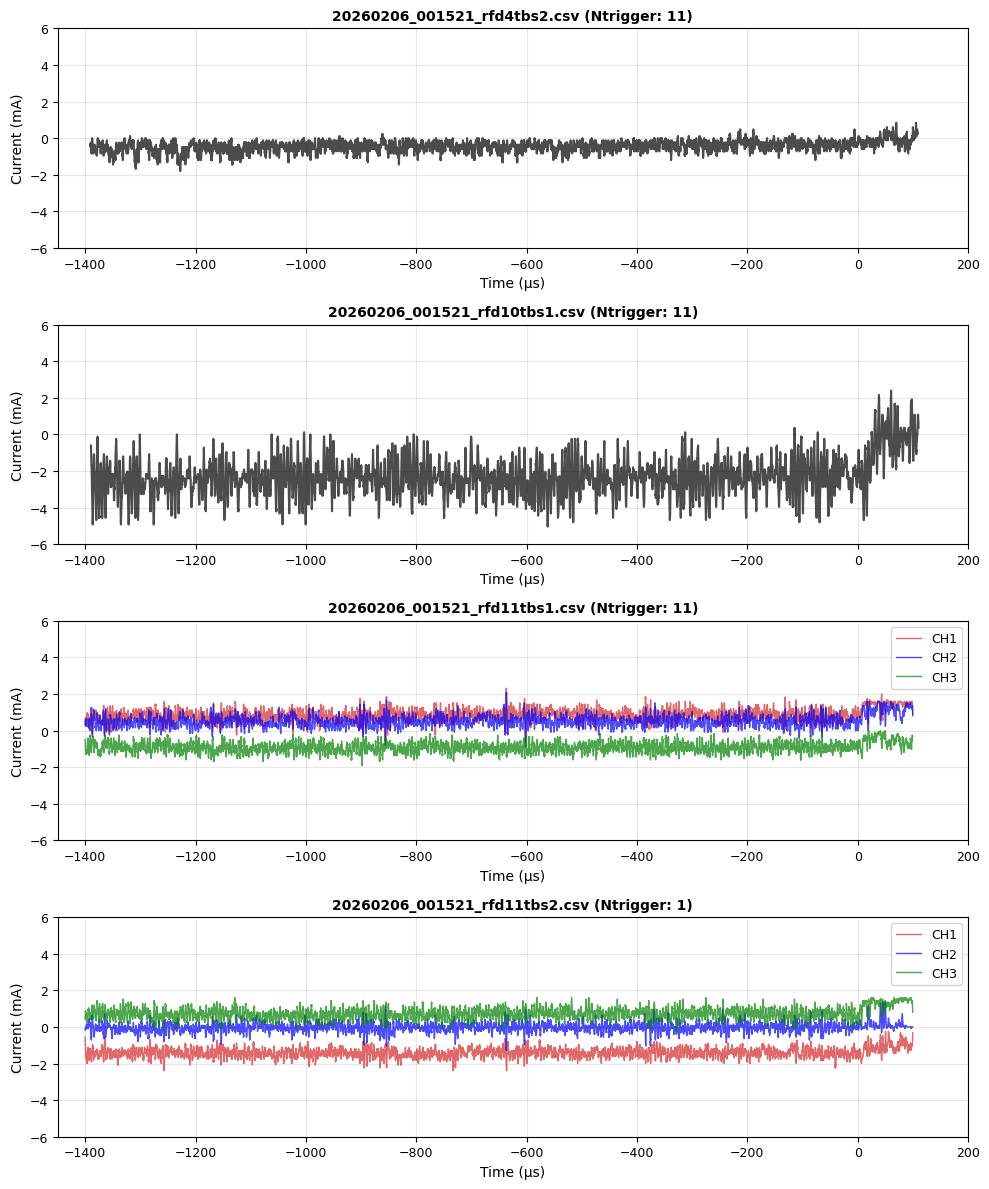


Plotting: 20260206 050910 (1 electrode files)
  No beam files found for this timestamp


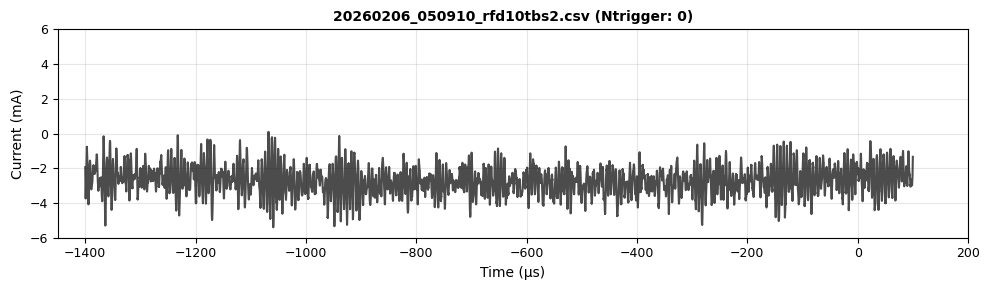


Plotting: 20260206 051022 (1 electrode files)
  No beam files found for this timestamp


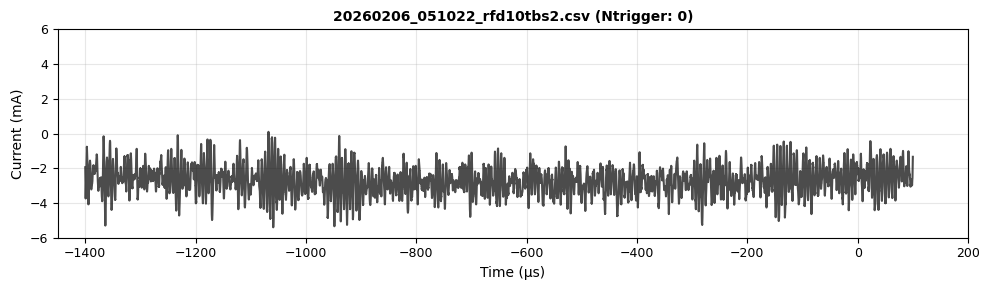


Plotting: 20260206 064319 (4 electrode files)
  No beam files found for this timestamp


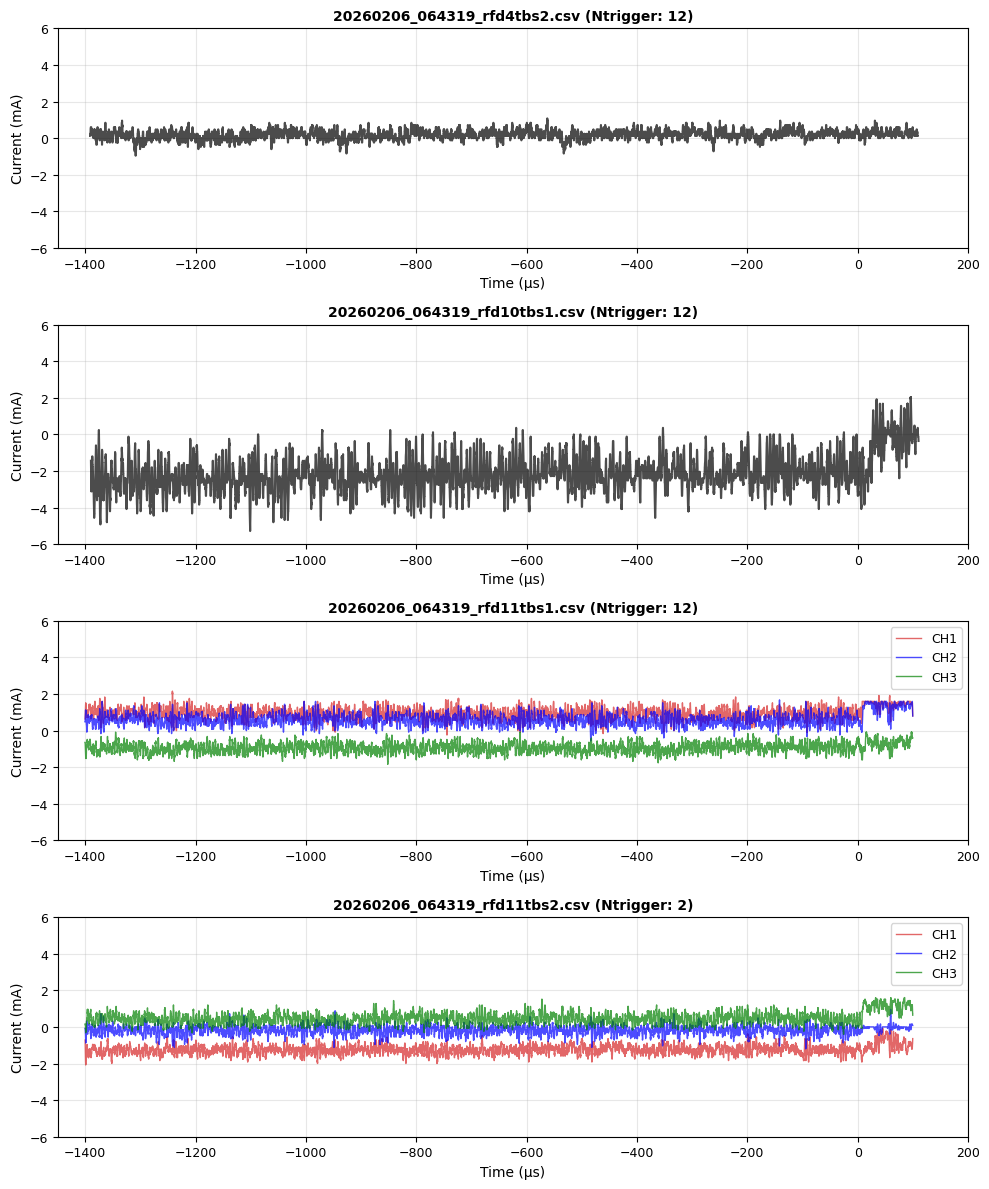

Plotting complete!


In [4]:
# ===== COMBINED ELECTRODE + BEAM POSITION PLOTTING =====
# Plot electrode signals alongside beam position data

if all_file_data:
    print("\n" + "="*60)
    print("PLOTTING ELECTRODE SIGNALS WITH BEAM POSITIONS")
    print("="*60)
    
    # Group files by date/time for plotting
    from collections import defaultdict
    date_time_groups = defaultdict(list)
    for file_data in all_file_data:
        key = (file_data['date'], file_data['time'])
        date_time_groups[key].append(file_data)
    
    for (date_str, time_str), file_data_list in sorted(date_time_groups.items()):
        print(f"\nPlotting: {date_str} {time_str} ({len(file_data_list)} electrode files)")
        
        # Get beam file info from first electrode file
        beam_files = file_data_list[0].get('beam_files', {})
        
        # Determine number of rows: electrode files + beam images (if available)
        n_beam_rows = len(beam_files)
        n_electrode_rows = len(file_data_list)
        n_total_rows = n_electrode_rows + n_beam_rows
        
        if n_beam_rows > 0:
            # Create grid: electrode signals on left, beam on right, plus beam images at bottom
            fig = plt.figure(figsize=(14, 3 * n_total_rows))
            gs = fig.add_gridspec(n_total_rows, 2, hspace=0.35, wspace=0.3)
            
            # Plot electrode signals
            for idx, file_data in enumerate(file_data_list):
                ax_e = fig.add_subplot(gs[idx, 0])
                
                # Construct title with Ntrigger if available
                title_suffix = ""
                if file_data.get('ntrigger'):
                    title_suffix = f" (Ntrigger: {file_data['ntrigger']})"
                
                # Plot filtered current
                for ch_name in file_data['channels']:
                    filtered_current_mA = file_data['current_data'][ch_name]
                    
                    if file_data['is_rfd11']:
                        ax_e.plot(file_data['time_us'], filtered_current_mA, color=color_map[ch_name], 
                                linewidth=1, alpha=0.7, label=ch_name)
                    else:
                        ax_e.plot(file_data['time_us'], filtered_current_mA, color='black', 
                                linewidth=1.5, alpha=0.7)
                
                ax_e.set_xlabel('Time (µs)', fontsize=10)
                ax_e.set_ylabel('Current (mA)', fontsize=10)
                ax_e.set_title(f'{file_data["filename"]} (Filtered){title_suffix}', fontsize=9, fontweight='bold')
                ax_e.grid(True, alpha=0.3)
                ax_e.tick_params(labelsize=9)
                ax_e.set_ylim(-6, 6)
                ax_e.set_xlim(-1450, 200)
                
                if file_data['is_rfd11']:
                    ax_e.legend(fontsize=9, loc='upper right')
            
            # Plot beam images
            beam_idx = 0
            for beam_type, beam_info in sorted(beam_files.items()):
                ax_b = fig.add_subplot(gs[n_electrode_rows + beam_idx, :])
                
                # Load and plot beam image
                beam_image = load_beam_file_as_image(beam_info['file'])
                
                if beam_image is not None:
                    if beam_image.shape[1] == 1:
                        # 1D data
                        ax_b.plot(beam_image.flatten(), linewidth=0.5)
                        ax_b.set_ylabel('Intensity', fontsize=10)
                        ax_b.set_xlabel('Pixel Index', fontsize=10)
                    else:
                        # 2D image
                        im = ax_b.imshow(beam_image, cmap='viridis', aspect='auto', origin='upper')
                        ax_b.set_ylabel('Y (pixels)', fontsize=10)
                        ax_b.set_xlabel('X (pixels)', fontsize=10)
                        cbar = plt.colorbar(im, ax=ax_b, label='Intensity')
                    
                    time_diff = beam_info['time_diff']
                    title_color = 'red' if time_diff > 1 else 'green'
                    ax_b.set_title(f'{beam_type}: {beam_info["filename"]} (Δt: {time_diff:.1f} min)', 
                                  fontsize=10, fontweight='bold', color=title_color)
                else:
                    ax_b.text(0.5, 0.5, f'Error loading {beam_type} beam file', 
                             ha='center', va='center', transform=ax_b.transAxes, fontsize=12, color='red')
                    ax_b.set_title(f'{beam_type}: {beam_info["filename"]}', fontsize=10, fontweight='bold')
                
                ax_b.grid(True, alpha=0.2)
                ax_b.tick_params(labelsize=9)
                beam_idx += 1
            
            plt.suptitle(f'{date_str} {time_str}: Electrode Signals + Beam Positions', 
                        fontsize=12, fontweight='bold', y=0.995)
            plt.show()
            
        else:
            # No beam files - plot electrode signals only
            print(f"  No beam files found for this timestamp")
            fig, axes = plt.subplots(n_electrode_rows, 1, figsize=(10, 3 * n_electrode_rows))
            if n_electrode_rows == 1:
                axes = [axes]
            
            for idx, file_data in enumerate(file_data_list):
                title_suffix = ""
                if file_data.get('ntrigger'):
                    title_suffix = f" (Ntrigger: {file_data['ntrigger']})"
                
                for ch_name in file_data['channels']:
                    filtered_current_mA = file_data['current_data'][ch_name]
                    
                    if file_data['is_rfd11']:
                        axes[idx].plot(file_data['time_us'], filtered_current_mA, color=color_map[ch_name], 
                                linewidth=1, alpha=0.7, label=ch_name)
                    else:
                        axes[idx].plot(file_data['time_us'], filtered_current_mA, color='black', 
                                linewidth=1.5, alpha=0.7)
                
                axes[idx].set_xlabel('Time (µs)', fontsize=10)
                axes[idx].set_ylabel('Current (mA)', fontsize=10)
                axes[idx].set_title(f'{file_data["filename"]}{title_suffix}', fontsize=10, fontweight='bold')
                axes[idx].grid(True, alpha=0.3)
                axes[idx].tick_params(labelsize=9)
                axes[idx].set_ylim(-6, 6)
                axes[idx].set_xlim(-1450, 200)
                
                if file_data['is_rfd11']:
                    axes[idx].legend(fontsize=9)
            
            plt.tight_layout()
            plt.show()

print("Plotting complete!")


In [6]:
# ===== DEBUG: Check beam file matching =====
print("="*60)
print("DEBUG: Beam File Matching Analysis")
print("="*60)

for date_str, time_str in sorted_date_times:
    print(f"\nElectrode: {date_str} {time_str}")
    matching_beams = find_matching_beam_files(date_str, time_str, beam_folder)
    
    if matching_beams:
        for beam_type, beam_info in matching_beams.items():
            print(f"  ✓ {beam_type}: {beam_info['filename']} (Δt: {beam_info['time_diff']:.1f} min)")
    else:
        print(f"  ✗ No beam files found (within tolerance)")


DEBUG: Beam File Matching Analysis

Electrode: 20260206 001521
  ✗ No beam files found (within tolerance)

Electrode: 20260206 050910
  ✗ No beam files found (within tolerance)

Electrode: 20260206 051022
  ✗ No beam files found (within tolerance)

Electrode: 20260206 064319
  ✗ No beam files found (within tolerance)
